# Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Importing The Dataset

In [2]:
data = pd.read_excel("bankruptcy-prevention (1).xlsx")
data

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,non-bankruptcy
246,1.0,1.0,0.5,1.0,1.0,0.0,non-bankruptcy
247,0.0,1.0,1.0,0.5,0.5,0.0,non-bankruptcy
248,1.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy


In [3]:
type(data)

pandas.core.frame.DataFrame

In [4]:
data.dtypes

industrial_risk           float64
 management_risk          float64
 financial_flexibility    float64
 credibility              float64
 competitiveness          float64
 operating_risk           float64
 class                     object
dtype: object

#### Describe the Data

In [5]:
data.describe()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,0.518000,0.614000,0.376000,0.470000,0.476000,0.570000
std,0.411526,0.410705,0.401583,0.415682,0.440682,0.434575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Check for missing values

In [6]:
data.isna().sum()

industrial_risk           0
 management_risk          0
 financial_flexibility    0
 credibility              0
 competitiveness          0
 operating_risk           0
 class                    0
dtype: int64

#### Check the data is balanced or imbalance

In [7]:
data[" class"].value_counts()

non-bankruptcy    143
bankruptcy        107
Name:  class, dtype: int64

In [8]:
data["class_yn"] = 1
data

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class,class_yn
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy,1
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy,1
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy,1
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy,1
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy,1
...,...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,non-bankruptcy,1
246,1.0,1.0,0.5,1.0,1.0,0.0,non-bankruptcy,1
247,0.0,1.0,1.0,0.5,0.5,0.0,non-bankruptcy,1
248,1.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy,1


#### Here we are changing the target variable to bankruptcy = 0, non-bankruptcy = 1

In [9]:
data.loc[data[' class'] == 'bankruptcy', 'class_yn'] = 0

In [10]:
data

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class,class_yn
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy,0
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy,0
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy,0
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy,0
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy,0
...,...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,non-bankruptcy,1
246,1.0,1.0,0.5,1.0,1.0,0.0,non-bankruptcy,1
247,0.0,1.0,1.0,0.5,0.5,0.0,non-bankruptcy,1
248,1.0,0.0,0.5,1.0,0.5,0.0,non-bankruptcy,1


In [11]:
data.drop(' class', inplace = True, axis =1)
data.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class_yn
0,0.5,1.0,0.0,0.0,0.0,0.5,0
1,0.0,1.0,0.0,0.0,0.0,1.0,0
2,1.0,0.0,0.0,0.0,0.0,1.0,0
3,0.5,0.0,0.0,0.5,0.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,0


In [12]:
data.dtypes

industrial_risk           float64
 management_risk          float64
 financial_flexibility    float64
 credibility              float64
 competitiveness          float64
 operating_risk           float64
class_yn                    int64
dtype: object

In [13]:
data["class_yn"].value_counts()

1    143
0    107
Name: class_yn, dtype: int64

# Data Visualisation

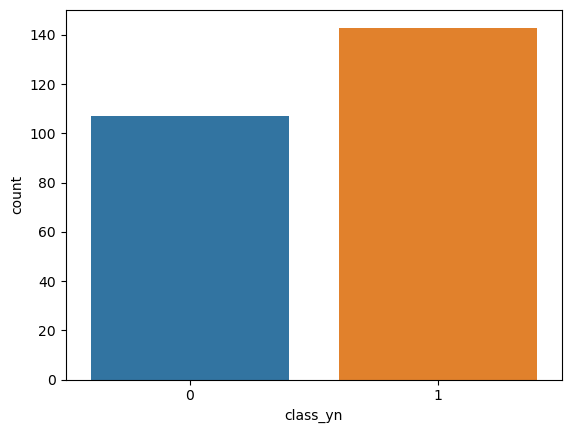

In [14]:
sns.countplot(x=data["class_yn"])
plt.show()

<Axes: xlabel=' financial_flexibility', ylabel='count'>

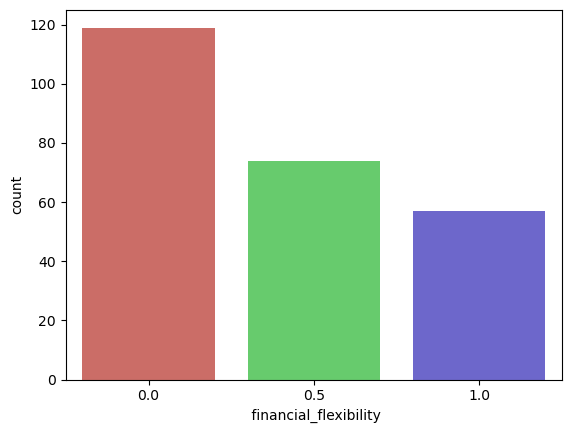

In [15]:
sns.countplot(x = ' financial_flexibility', data = data, palette = 'hls')

<Axes: xlabel='class_yn'>

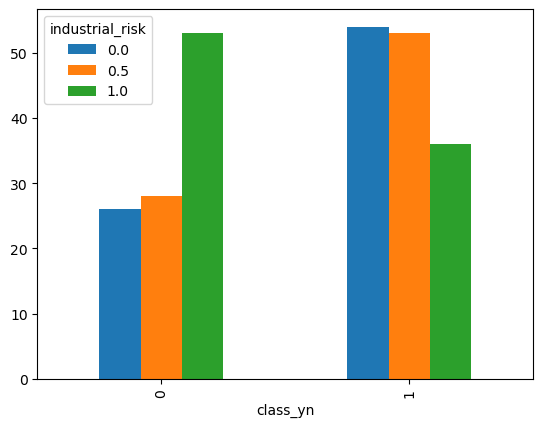

In [16]:
pd.crosstab(data.class_yn, data.industrial_risk).plot(kind='bar')

In [17]:
data.columns

Index(['industrial_risk', ' management_risk', ' financial_flexibility',
       ' credibility', ' competitiveness', ' operating_risk', 'class_yn'],
      dtype='object')

<Axes: xlabel=' financial_flexibility'>

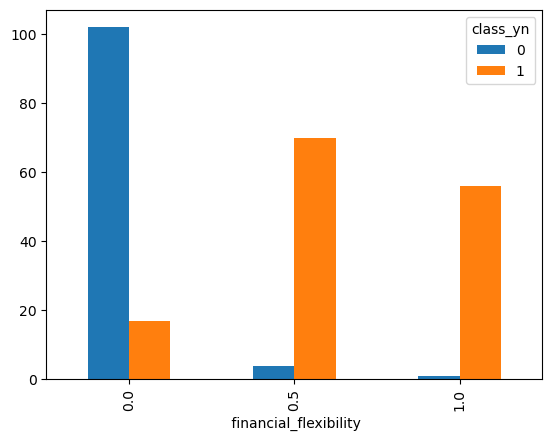

In [18]:
pd.crosstab(data[' financial_flexibility'], data['class_yn']).plot(kind = 'bar')

<Axes: xlabel=' credibility'>

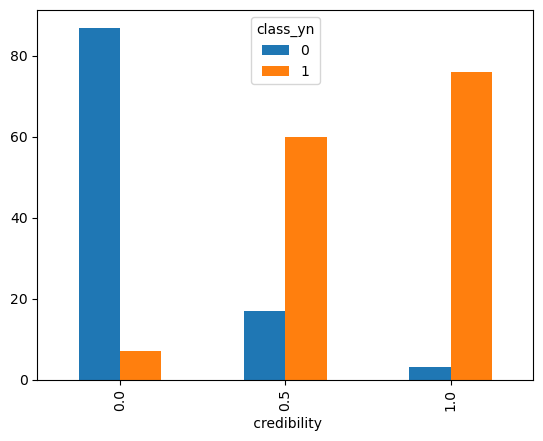

In [19]:
pd.crosstab(data[' credibility'], data.class_yn).plot(kind = 'bar')

<Axes: xlabel=' operating_risk'>

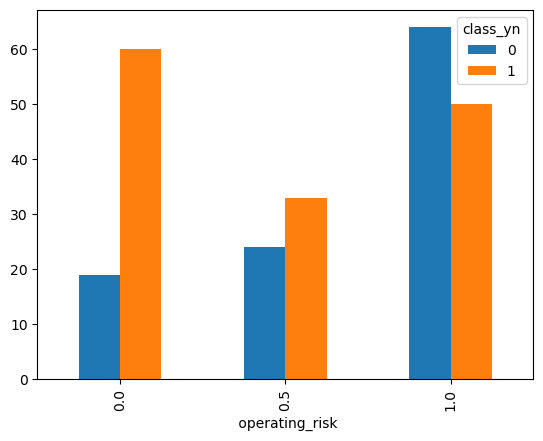

In [20]:
pd.crosstab(data[' operating_risk'], data.class_yn).plot(kind='bar')

<Axes: xlabel=' financial_flexibility'>

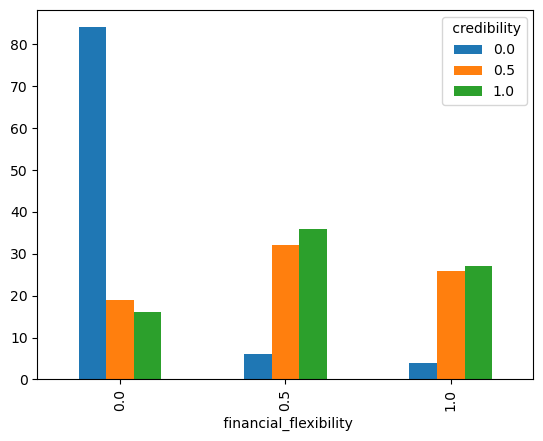

In [21]:
pd.crosstab(data[' financial_flexibility'], data[' credibility']).plot(kind = 'bar')

In [22]:
np.shape(data)

(250, 7)

## Histogram Plot

array([[<Axes: title={'center': 'industrial_risk'}>,
        <Axes: title={'center': ' management_risk'}>,
        <Axes: title={'center': ' financial_flexibility'}>],
       [<Axes: title={'center': ' credibility'}>,
        <Axes: title={'center': ' competitiveness'}>,
        <Axes: title={'center': ' operating_risk'}>],
       [<Axes: title={'center': 'class_yn'}>, <Axes: >, <Axes: >]],
      dtype=object)

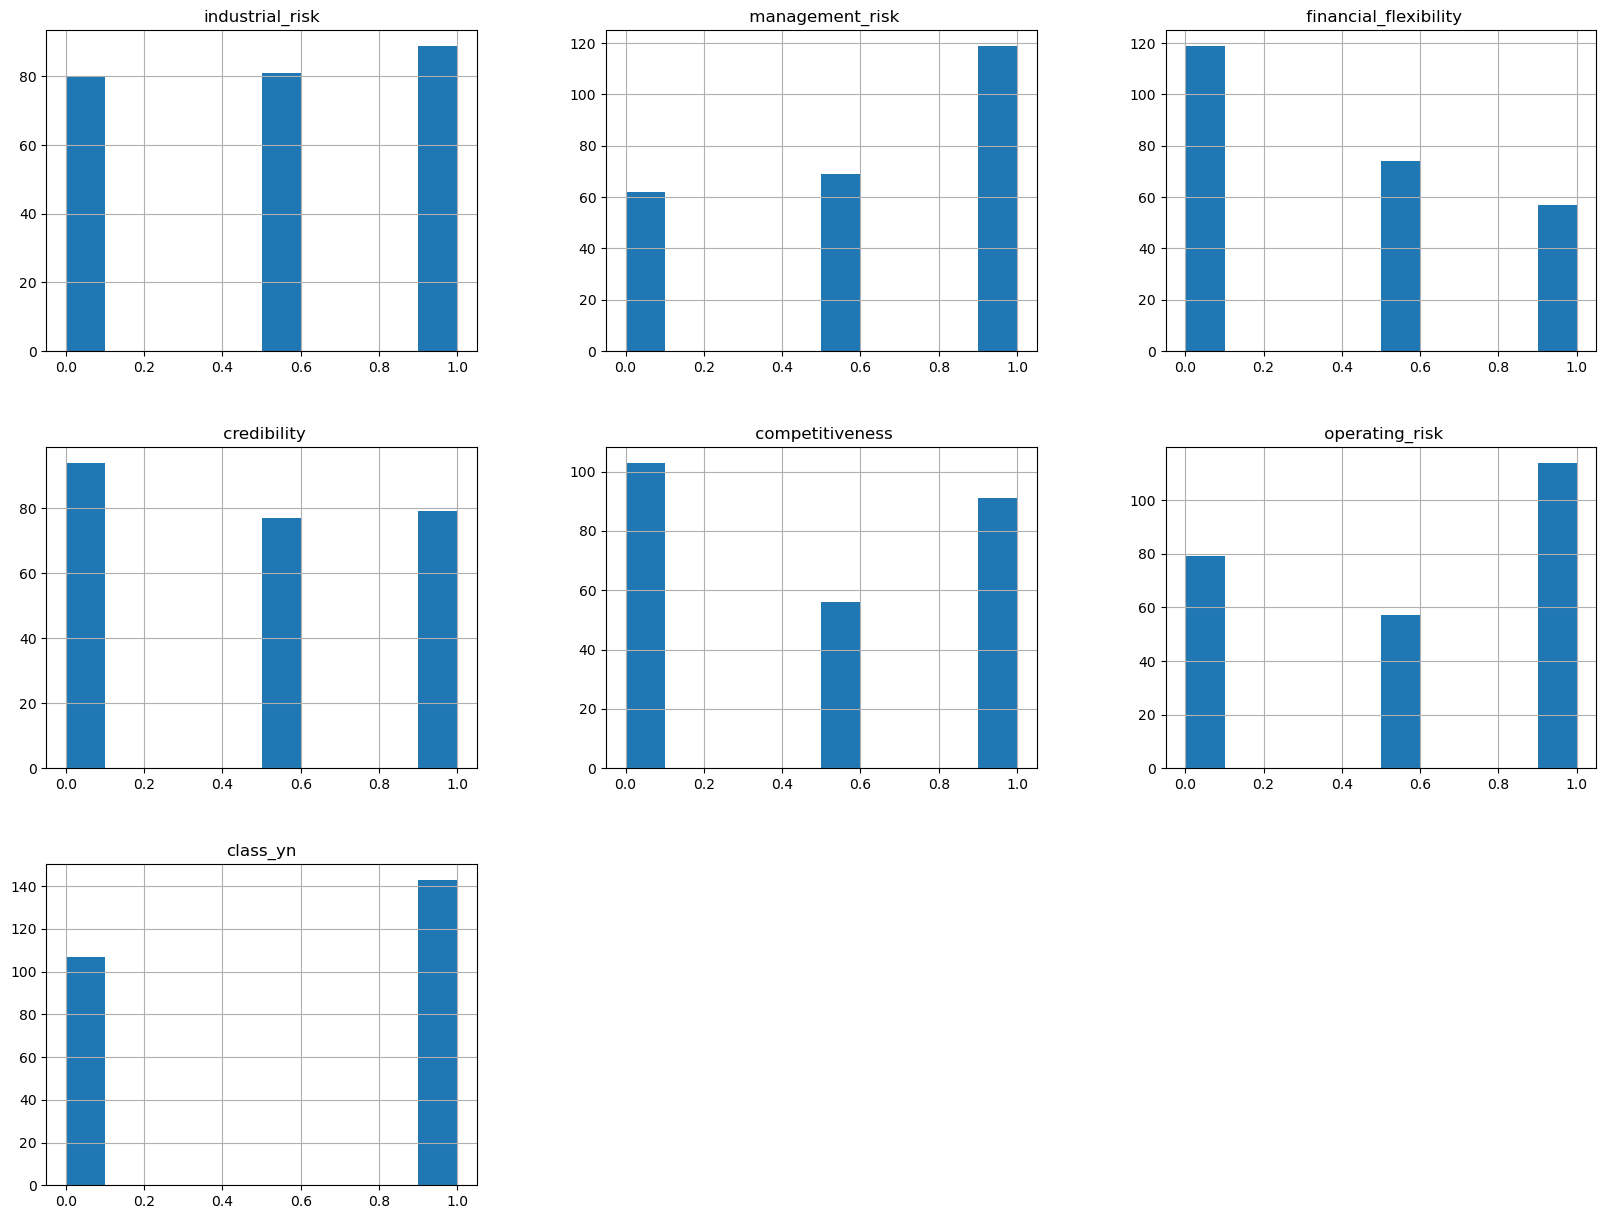

In [23]:
data.hist(figsize=(20, 15))

## Boxplot

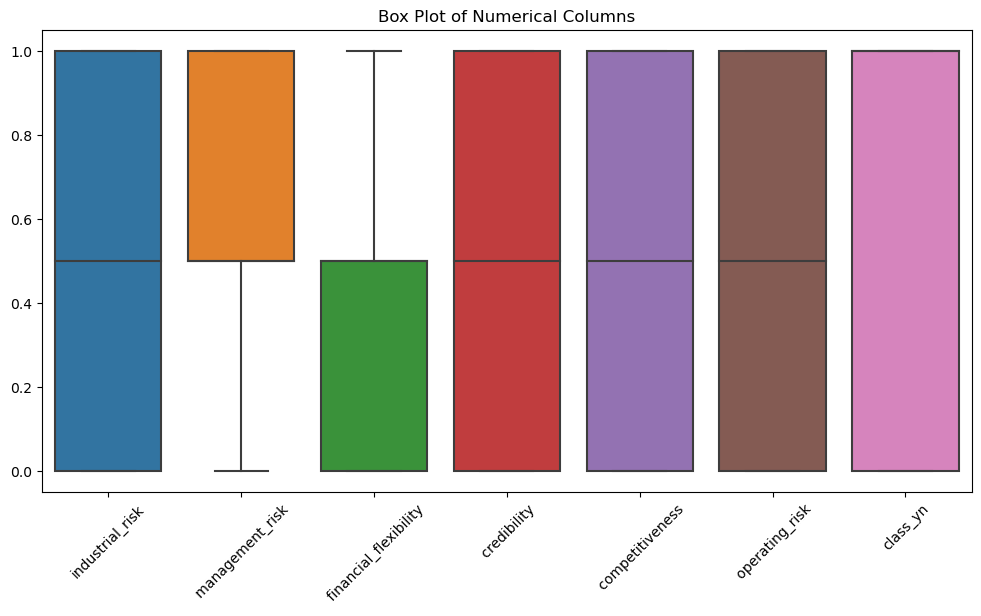

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title("Box Plot of Numerical Columns")
plt.xticks(rotation=45)
plt.show()

## Pairplot

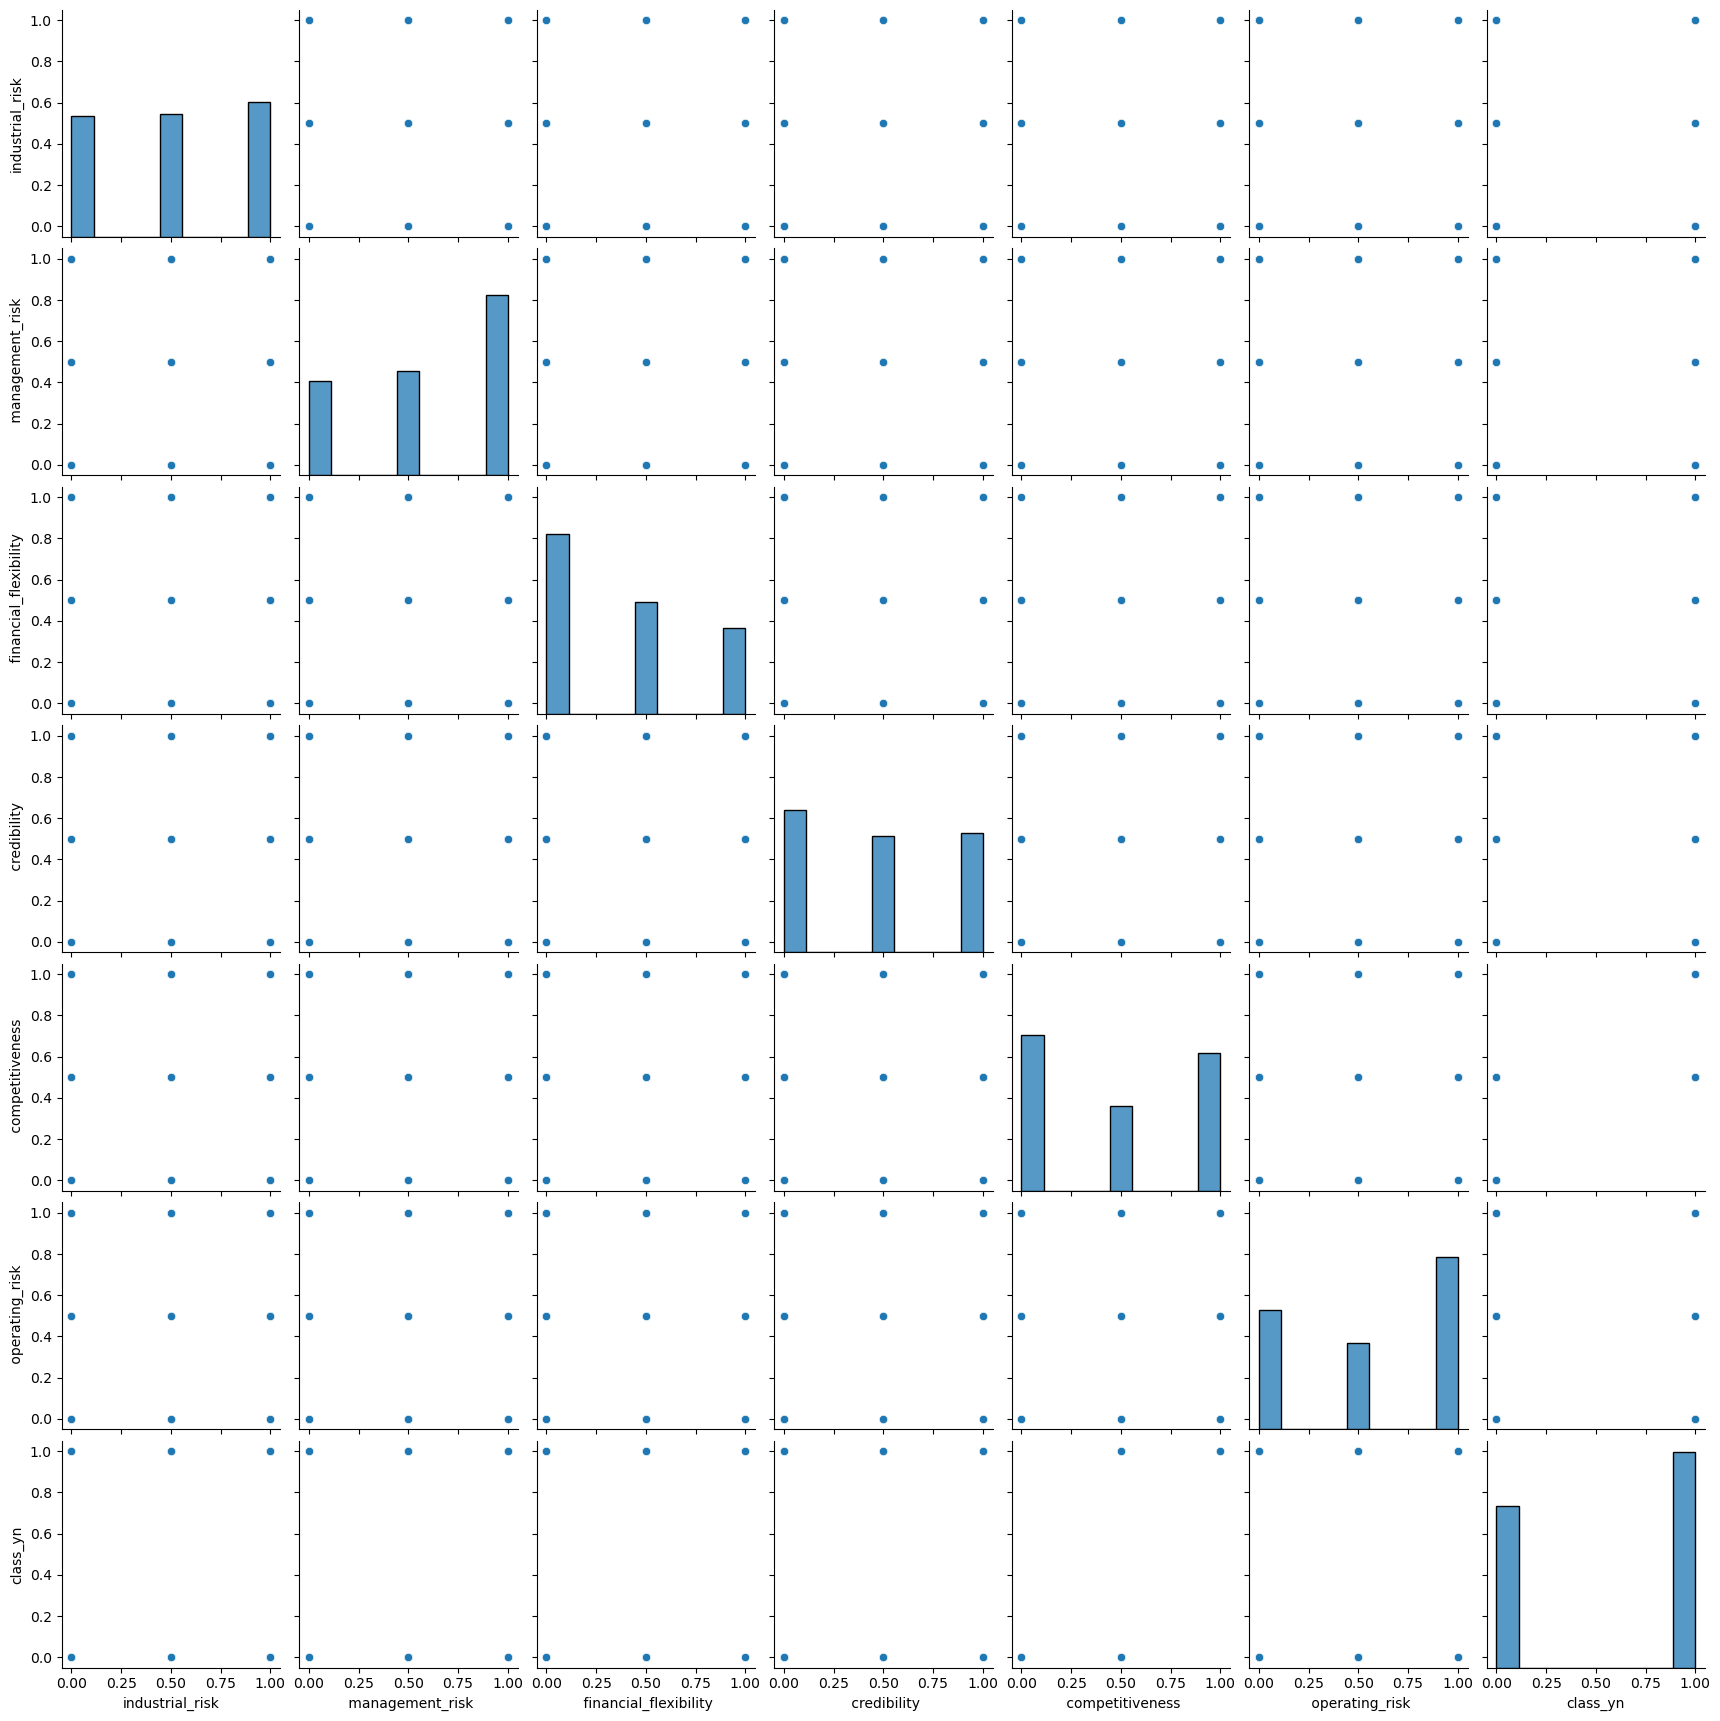

In [25]:
sns.pairplot(data)

## Correlation matrix

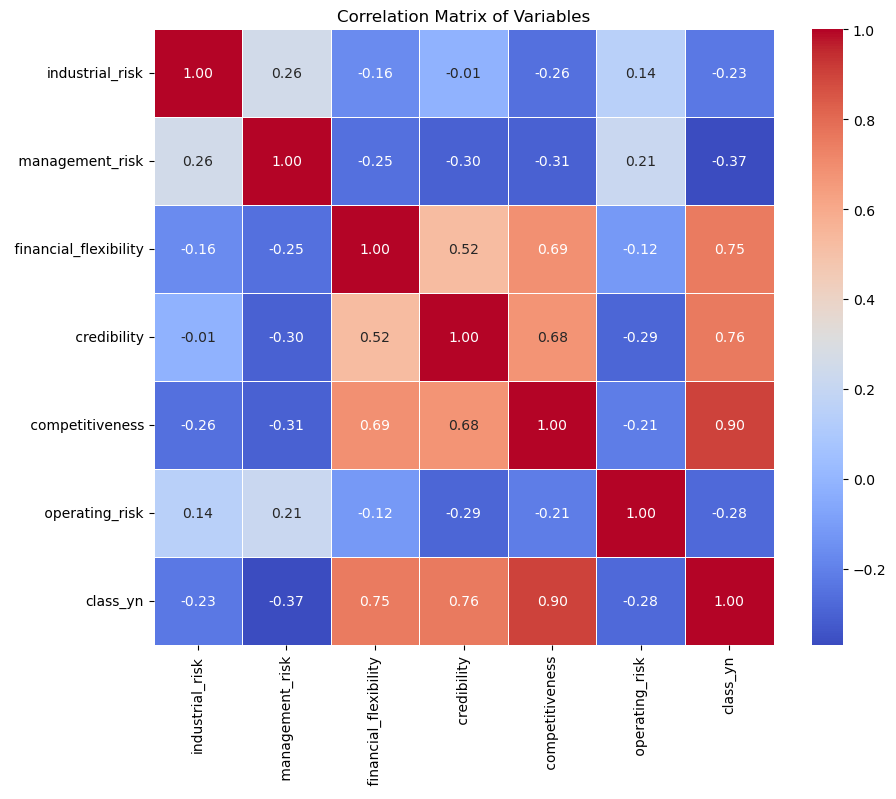

In [26]:
# Compute the correlation matrix
correlation_matrix = data.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Variables')
plt.show()

#### Feature Engineering and Model Building

In [27]:
# Input
x = data.iloc[:,:-1]

# Target variable

y = data.iloc[:,-1]

In [28]:
x

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk
0,0.5,1.0,0.0,0.0,0.0,0.5
1,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0
3,0.5,0.0,0.0,0.5,0.0,1.0
4,1.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0
246,1.0,1.0,0.5,1.0,1.0,0.0
247,0.0,1.0,1.0,0.5,0.5,0.0
248,1.0,0.0,0.5,1.0,0.5,0.0


In [29]:
y

0      0
1      0
2      0
3      0
4      0
      ..
245    1
246    1
247    1
248    1
249    1
Name: class_yn, Length: 250, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split # train and test
from sklearn import metrics
from sklearn import preprocessing 
from sklearn.metrics import classification_report

# Sliptting the data into train and test

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state = 0)

In [32]:
x_train.shape

(187, 6)

In [33]:
y_train.shape

(187,)

In [34]:
x_test.shape

(63, 6)

In [35]:
y_test.shape

(63,)

# Preparing Model

## 1. Logistic Regression


In [36]:
from sklearn.linear_model import LogisticRegression

logisticlassifier = LogisticRegression() 

In [37]:
logisticlassifier.fit(x_train, y_train)

logisticlassifier.coef_ # coefficients of features

array([[-0.43044914, -0.73309162,  2.37729553,  2.31022854,  3.68601327,
        -0.53101906]])

#### After the traing the model then we prediction on test data

In [38]:
y_pred = logisticlassifier.predict(x_test)
y_pred

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0],
      dtype=int64)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [40]:
a = accuracy_score(y_test,y_pred)
a

1.0

In [41]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, logisticlassifier.predict_proba(x_test)[:,1])

In [42]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
ROC-AUC score: 1.0


### From the accuracy we can say that the model is overfitted to avoid overfit problem we use Regularization method

#### here we have L1, L2 regularization

#### It turns out they have different but equally useful properties. From a practical standpoint, L1 tends to shrink coefficients to zero whereas L2 tends to shrink coefficients evenly. L1 is therefore useful for feature selection, as we can drop any variables associated with coefficients that go to zero.

### L1 = lasso regularization

In [43]:
from sklearn import linear_model

lasso_reg = linear_model.Lasso(alpha = 50, max_iter = 100, tol =0.1)

lasso_reg.fit(x_train, y_train)

Lasso(alpha=50, max_iter=100, tol=0.1)

In [44]:
lasso_reg.score(x_test, y_test)

-0.0017265366431771234

In [45]:
lasso_reg.score(x_train, y_train)

0.0

### L2 = Ridge regularization

In [46]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha = 50, max_iter = 100, tol = 0.1)

ridge_reg.fit(x_train, y_train)

Ridge(alpha=50, max_iter=100, tol=0.1)

In [47]:
ridge_reg.score(x_test, y_test)

0.768839856224332

In [48]:
ridge_reg.score(x_train, y_train)

0.7452859981668727

##  2. KNN model

In [49]:
from sklearn.neighbors import KNeighborsClassifier as KNC
import warnings
warnings.filterwarnings('ignore')

#### To choose k value

In [50]:
import math
math.sqrt(len(y_test))

7.937253933193772

#### Here we are choosing the k value to be 7 (choosing odd value)

#### Define the model KNN and fit model

In [51]:
KNN_classifier = KNC(n_neighbors =7, p = 2, metric = 'euclidean')

In [52]:
KNN_classifier.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

### Predict the Test set results

In [53]:
y_pred = KNN_classifier.predict(x_test)
y_pred

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0],
      dtype=int64)

### Evaluate model

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[26  0]
 [ 1 36]]


In [55]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, KNN_classifier.predict_proba(x_test)[:,1])

In [56]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC score:", roc_auc)

Accuracy: 0.9841269841269841
Precision: 1.0
Recall: 0.972972972972973
F1-score: 0.9863013698630138
ROC-AUC score: 1.0


### 3. Support Vector Machine

In [57]:
from sklearn.svm import SVC

#### Kernel = Linear model

In [58]:
model_linear = SVC(kernel = 'linear')

model_linear.fit(x_train, y_train)

pred_test_linear = model_linear.predict(x_test)

np.mean(pred_test_linear==y_test)

1.0

In [59]:
# Metrics
accuracy = accuracy_score(y_test, pred_test_linear)
precision = precision_score(y_test, pred_test_linear)
recall = recall_score(y_test, pred_test_linear)
f1 = f1_score(y_test, pred_test_linear)

In [60]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


#### Kernel = 'rbf' model --> Radial Basis Function

In [61]:
model_rbf = SVC(kernel = "rbf")
model_rbf.fit(x_train,y_train)
pred_test_rbf = model_rbf.predict(x_test)

np.mean(pred_test_rbf==y_test) # Accuracy

1.0

In [62]:
# Metrics
accuracy = accuracy_score(y_test, pred_test_rbf)
precision = precision_score(y_test, pred_test_rbf)
recall = recall_score(y_test, pred_test_rbf)
f1 = f1_score(y_test, pred_test_rbf)

In [63]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


#### Kernel = ploy model

In [64]:
model_poly = SVC(kernel = "poly")
model_poly.fit(x_train,y_train)
pred_test_poly = model_poly.predict(x_test)

np.mean(pred_test_poly==y_test) # Accuracy

0.9841269841269841

In [65]:
# Metrics
accuracy = accuracy_score(y_test, pred_test_poly)
precision = precision_score(y_test, pred_test_poly)
recall = recall_score(y_test, pred_test_poly)
f1 = f1_score(y_test, pred_test_poly)

In [66]:
# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9841269841269841
Precision: 1.0
Recall: 0.972972972972973
F1-score: 0.9863013698630138


### from the above kernels in SVM polynomial kernel is giving best accuracy

# For Model Deployment We Are Using SVM as are final Model